In [51]:
import pandas as pd
import random
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network

In [52]:
N = 100
p = 0.05
gh = nx.erdos_renyi_graph(N, p)

In [53]:
gh.nodes(), gh.edges()

(NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99)),
 EdgeView([(0, 12), (0, 38), (0, 80), (0, 93), (1, 7), (1, 24), (1, 50), (1, 52), (1, 74), (2, 57), (3, 6), (3, 8), (3, 54), (4, 7), (4, 13), (4, 15), (4, 17), (4, 26), (4, 49), (4, 74), (4, 87), (5, 25), (5, 73), (5, 81), (6, 10), (6, 11), (6, 21), (6, 23), (6, 34), (6, 59), (6, 95), (7, 41), (7, 47), (7, 70), (7, 81), (8, 25), (8, 47), (8, 52), (8, 59), (8, 67), (9, 32), (9, 53), (10, 20), (10, 73), (10, 90), (11, 37), (11, 93), (12, 29), (12, 37), (12, 74), (12, 75), (12, 90), (13, 17), (13, 75), (14, 23), (14, 44), (14, 63), (14, 64), (14, 75), (15, 33), (15, 59), (15, 62), (15, 77), (1

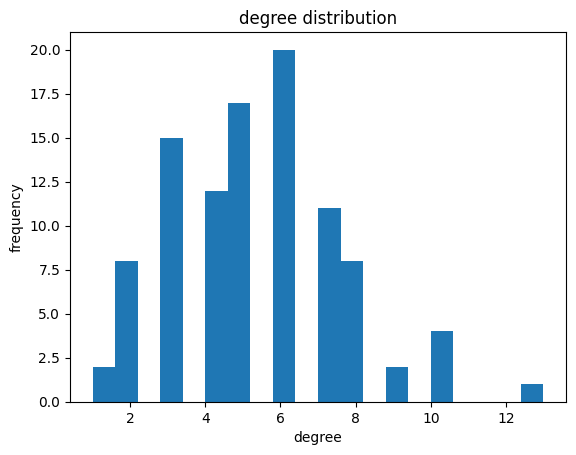

In [ ]:
node_degrees = dict(gh.degree())
plt.Figure(figsize=(4, 4))
plt.hist(node_degrees.values(), bins=20)
plt.xlabel("degree")
plt.ylabel("frequency")
plt.title("degree distribution")
plt.show()

In [55]:
betweenness = nx.betweenness_centrality(gh)
closness = nx.closeness_centrality(gh)
clustering = nx.clustering(gh)
page_rank = nx.pagerank(gh)

if nx.is_connected(gh):
    avg_path = nx.average_shortest_path_length(gh)
    diameter = nx.diameter(gh)
else:
    largest_cc = max(nx.connected_components(gh), key=len)
    subgraph = gh.subgraph(largest_cc)
    avg_path = nx.average_shortest_path_length(subgraph)
    diameter = nx.diameter(subgraph)

num_components = nx.number_connected_components(gh)

In [56]:
pd.DataFrame({
    'Betweenness': pd.Series(betweenness),
    'Closeness': pd.Series(closness),
    'Clustering_Coeff': pd.Series(clustering),
    'PageRank': pd.Series(page_rank),
    'Avg_Shortest_Path': avg_path,
    'Diameter': diameter,
    'Num_Components': num_components
}).describe()

,Betweenness,Closeness,Clustering_Coeff,PageRank,Avg_Shortest_Path,Diameter,Num_Components
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.0,100.0
mean,0.019695,0.344551,0.040136,0.010000,2.930101,6.0,1.0
std,0.016443,0.032891,0.062951,0.003565,0.000000,0.0,0.0
min,0.000000,0.248744,0.000000,0.003134,2.930101,6.0,1.0
25%,0.006842,0.321429,0.000000,0.007304,2.930101,6.0,1.0
50%,0.015779,0.348592,0.000000,0.009825,2.930101,6.0,1.0
75%,0.028904,0.364306,0.071429,0.012300,2.930101,6.0,1.0
max,0.087762,0.428571,0.333333,0.021886,2.930101,6.0,1.0


In [57]:
nx.number_connected_components(gh)

1

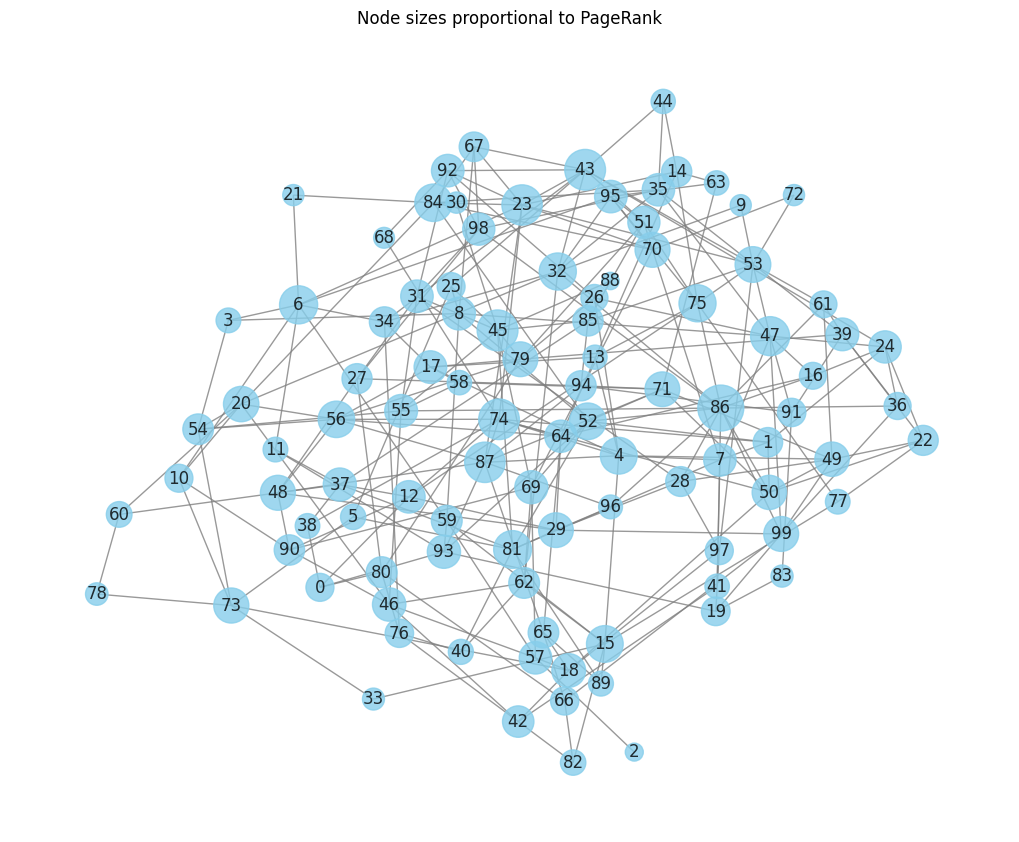

In [58]:
pagerank = nx.pagerank(gh)


sizes = [v * 50000 for v in pagerank.values()]

plt.figure(figsize=(10, 8))
pos = nx.forceatlas2_layout(gh)

nx.draw(gh, pos, 
        node_size=sizes,
        node_color="skyblue",
        with_labels=True,
        edge_color="gray",
        alpha=0.8)

plt.title("Node sizes proportional to PageRank")
plt.show()